In [1]:
# load libraries

# Machine Learning and Data Science Libraries
import numpy as np  # to handle arrays
import pandas as pd  # to handle dataframes
import matplotlib.pyplot as plt  # to plot graphs
import seaborn as sns  # to plot graphs
from sklearn.model_selection import train_test_split  # to split data into training and test sets
from sklearn.preprocessing import StandardScaler  # to standardize the data
from sklearn.tree import DecisionTreeClassifier  # Decision Tree model
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Ensemble models
from sklearn.linear_model import LogisticRegression  # Logistic Regression model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # to evaluate the model
from sklearn.model_selection import cross_validate  # to perform cross-validation

In [2]:
from imblearn.over_sampling import SMOTE  # to handle imbalanced data
import warnings  # to ignore warnings
warnings.filterwarnings('ignore')

# Essential libraries
import json # to handle JSON files

In [3]:
# function to convert string keys to integer keys in a dictionary
def str_to_int(str_dict):
    return {int(k): v for k, v in str_dict.items()}

In [4]:
# load mapping JSON files, manually created for data visualization purposes
 
with open('./predict+students+dropout+and+academic+success/mapping/marital_status.json', 'r') as f:
    marital_status_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/nationality.json', 'r') as f:
    nationality_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/application_mode.json', 'r') as f:
    application_mode_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/course.json', 'r') as f:
    course_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/father_occupations.json', 'r') as f:
    father_occupations_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/mother_occupations.json', 'r') as f:
    mother_occupations_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/previous_qualification.json', 'r') as f:
    previous_qualification_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/father_qualifications.json', 'r') as f:
    father_qualifications_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/mother_qualifications.json', 'r') as f:
    mother_qualifications_json = str_to_int(json.load(f))

## Step 1 - Data Collection and Preprocessing

In [5]:
data = pd.read_csv("predict+students+dropout+and+academic+success/data.csv", sep=";")  # load dataset

In [6]:
# rename columns
data.columns = [["Marital status", "Application mode", "Application order", "Course", "Daytime/evening attendance",
                 "Previous qualification", "Previous qualification (grade)", "Nationality", "Mother's qualification",
                 "Father's qualification", "Mother's occupation", "Father's occupation", "Admission grade",
                 "Displaced", "Educational special needs", "Debtor", "Tuition fees up to date", "Gender",
                 "Scholarship holder", "Age at enrollment", "International", "Curricular units 1st sem (credited)",
                 "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (evaluations)",
                 "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
                 "Curricular units 1st sem (without evaluations)",
                 "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
                 "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
                 "Curricular units 2nd sem (grade)", "Curricular units 2nd sem (without evaluations)",
                 "Unemployment rate", "Inflation rate", "GDP", "Target"
                 ]]

In [7]:
# get X and y for training add testing
X = data.drop(columns=['Target'])
y = data['Target']

# apply train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
# Select relevant features for modeling
data_selected = data[["Daytime/evening attendance", "Admission grade", 
                      "Displaced", "Educational special needs", "Debtor", "Tuition fees up to date", 
                 "Scholarship holder", "Age at enrollment", "International", 
                 
                 "Curricular units 1st sem (credited)",
                 "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (evaluations)",
                 "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
                 "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
                 "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
                 "Curricular units 2nd sem (grade)", 
                 
                 "Target"]]  

In [9]:
# Prepare the data for SMOTE
# First separate features and target
X_selected = data_selected.drop('Target', axis=1, level = 0)   # drop target, rest are features
y_selected = data_selected['Target']  # assign target

## Step 5 - Imbalance data Handling (Bias Evaluation and Mitigation)

In [10]:
# Split the data into training and testing sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y_selected, test_size=0.2, random_state=42, stratify=y)

In [11]:
# Scale the features before applying SMOTE
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training set & transform
X_train_scaled = scaler.fit_transform(X_train_selected)

# Use the same transformation on test set
X_test_scaled = scaler.transform(X_test_selected)


In [12]:
# Apply SMOTE to training data only
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)   # initialize SMOTE
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_selected)  # apply SMOTE

In [13]:
# Print class distribution before and after SMOTE
print("Original class distribution in training set:")
print(y_train_selected.value_counts(), "\n")

print("Class distribution after SMOTE:")
print(y_train_resampled["Target"].value_counts())

Original class distribution in training set:
(Target,)
Graduate     1767
Dropout      1137
Enrolled      635
Name: count, dtype: int64 

Class distribution after SMOTE:
(Target,)
Dropout      1767
Enrolled     1767
Graduate     1767
Name: count, dtype: int64


In [14]:
# Store the resampled data for later use
train_resampled = pd.DataFrame(X_train_resampled, columns=X_selected.columns)   # convert back to dataframe
train_resampled['Target'] = y_train_resampled                          # add target column

In [15]:
# Flatten column names (convert tuple ('Feature',) → 'Feature')
X_test_selected.columns = [col[0] if isinstance(col, tuple) else col for col in X_test_selected.columns]
train_resampled.columns = [col[0] if isinstance(col, tuple) else col for col in train_resampled.columns]
X_train_resampled = train_resampled.drop('Target', axis=1)   # features
y_train_resampled = train_resampled['Target']                 # target

## Step 6 - Adding appropriate explanations to the model
provide both local and global explanations

In [16]:
import shap
# Use the best performing model from previous step, e.g., xgboost
best_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
best_model.fit(X_train_resampled, y_train_resampled)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [17]:
# Explain the model's predictions using SHAP
explainer = shap.Explainer(best_model.predict_proba, X_train_resampled)
shap_values = explainer(X_test_selected)

dropout_class_index = 0

PermutationExplainer explainer: 886it [02:05,  6.78it/s]                         


In [31]:
import shap

# Map class indices
class_names = ["Graduate", "Dropout", "Enrolled"]

# Create SHAP explanation objects per class
shap_explanations = {
    cls: shap.Explanation(
        values=shap_values.values[..., i],
        base_values=shap_values.base_values[..., i],
        data=shap_values.data,
        feature_names=X_train_resampled.columns
    )
    for i, cls in enumerate(class_names)
}

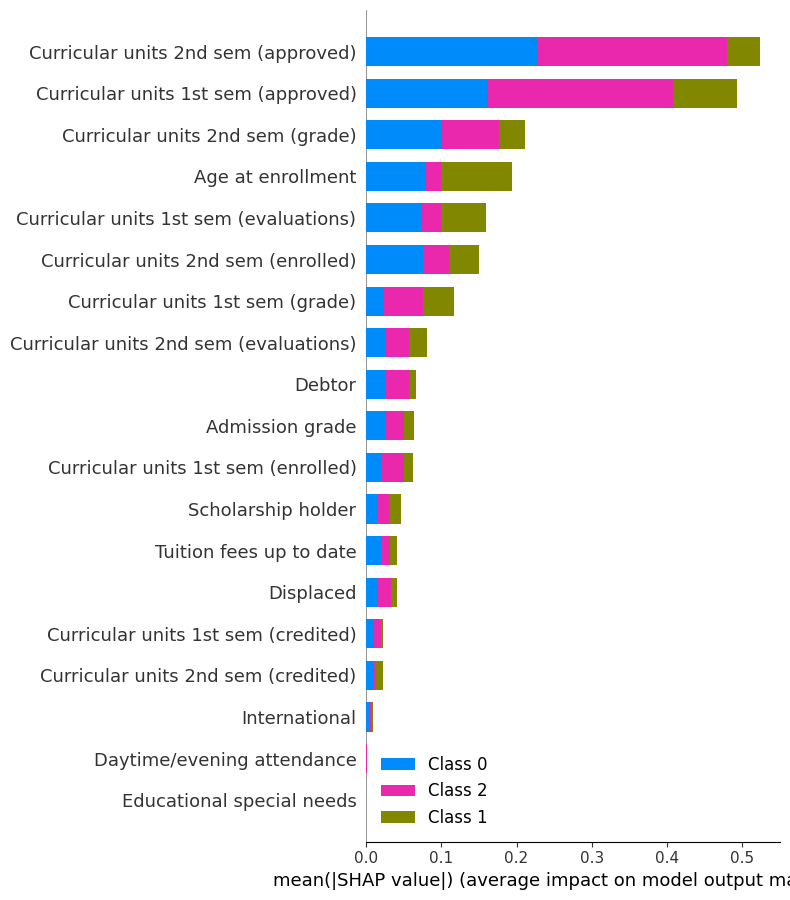

In [32]:
# Global explanation
shap.summary_plot(shap_values, X_test_selected, plot_type="bar")

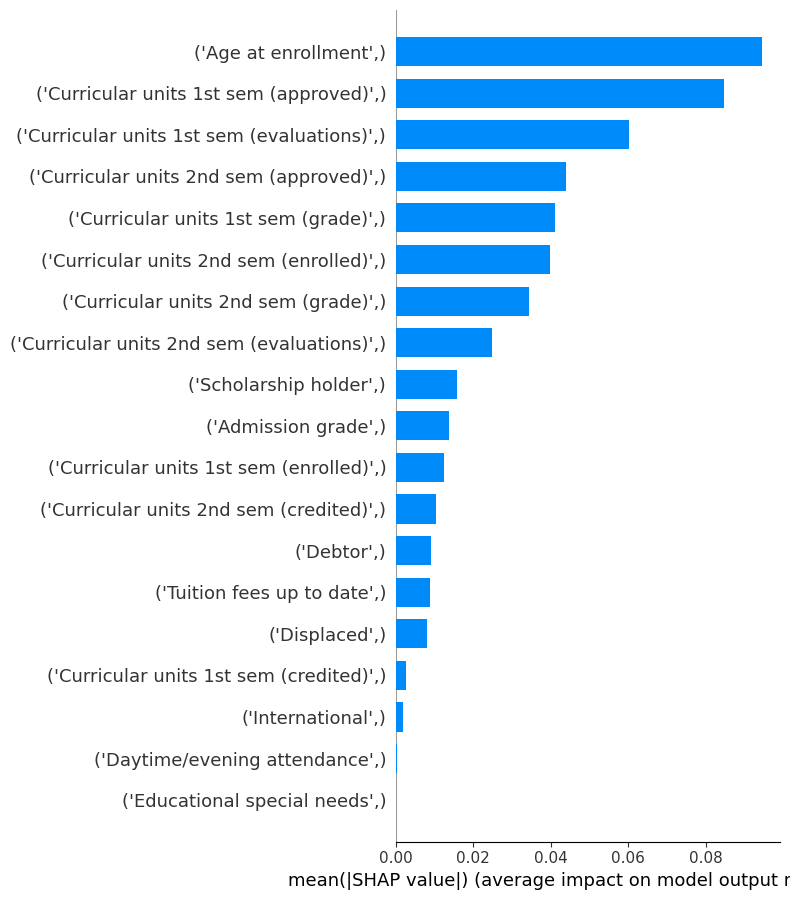

In [33]:
shap.summary_plot(
    shap_explanations["Dropout"].values,
    X_test_selected,
    feature_names=X_selected.columns,
    plot_type="bar"
)

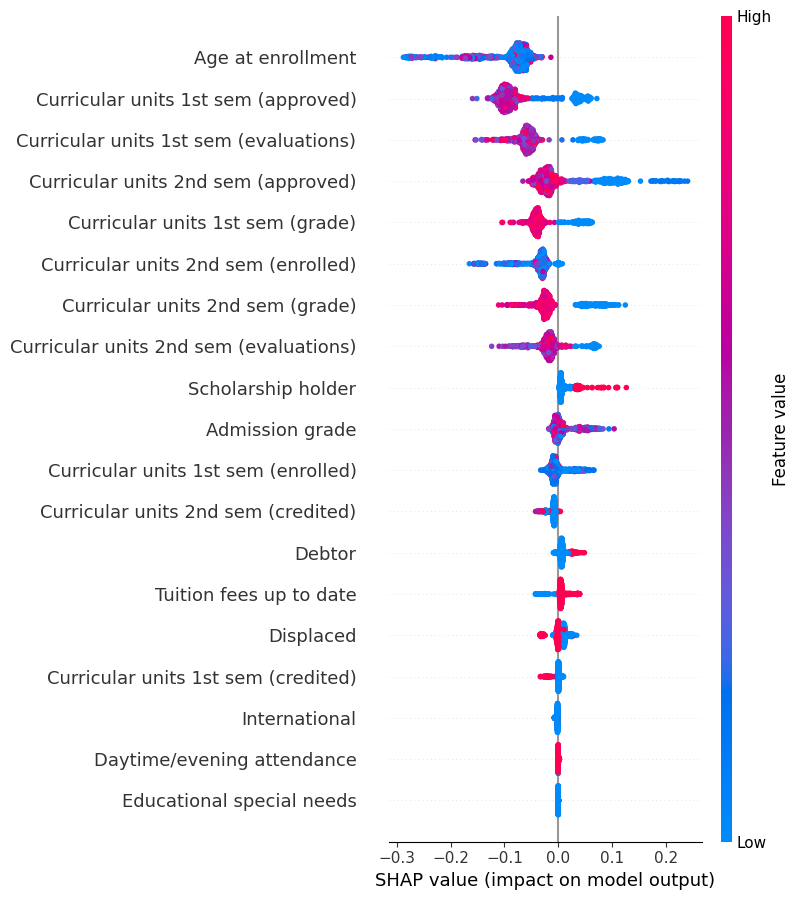

In [34]:
shap.summary_plot(shap_values[..., 1], X_test_selected, feature_names=X_test_selected.columns, show=True)

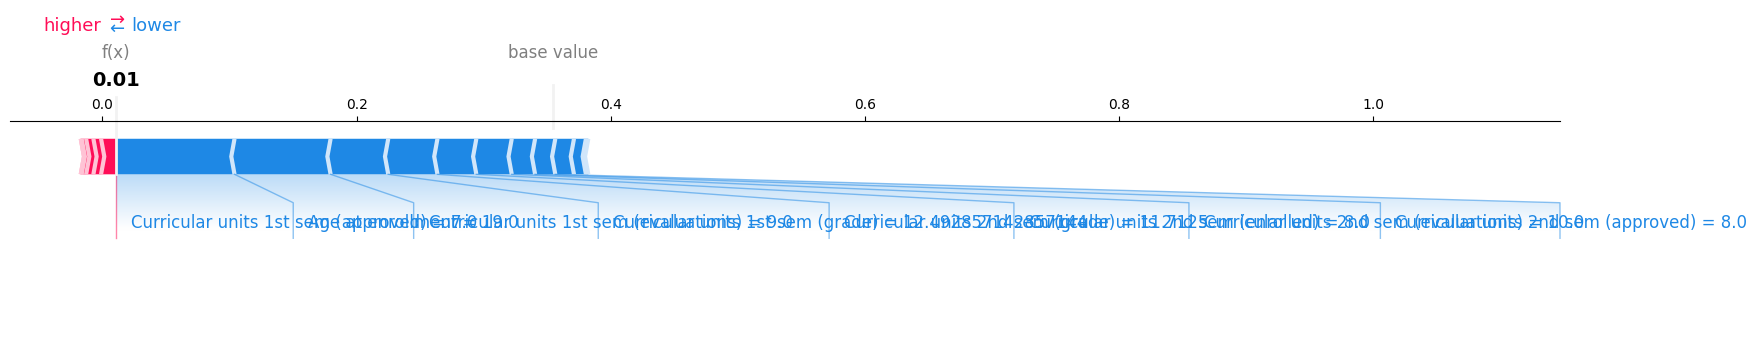

In [35]:
idx = 1  # index of the sample to explain
# Local force plot (no explainer.expected_value)
shap.plots.force(
    shap_values[idx, :, 1],  # single sample
    matplotlib=True
)

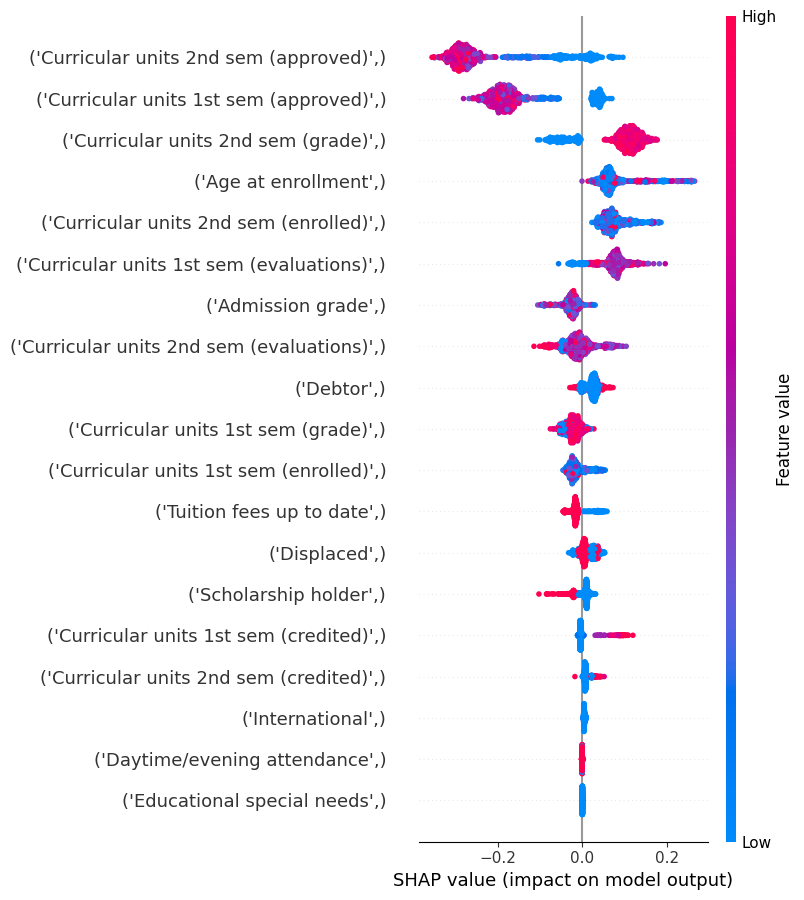

In [36]:
shap.summary_plot(
    shap_values[..., dropout_class_index],
    X_test_selected,
    feature_names=X_selected.columns,
    show=True
)

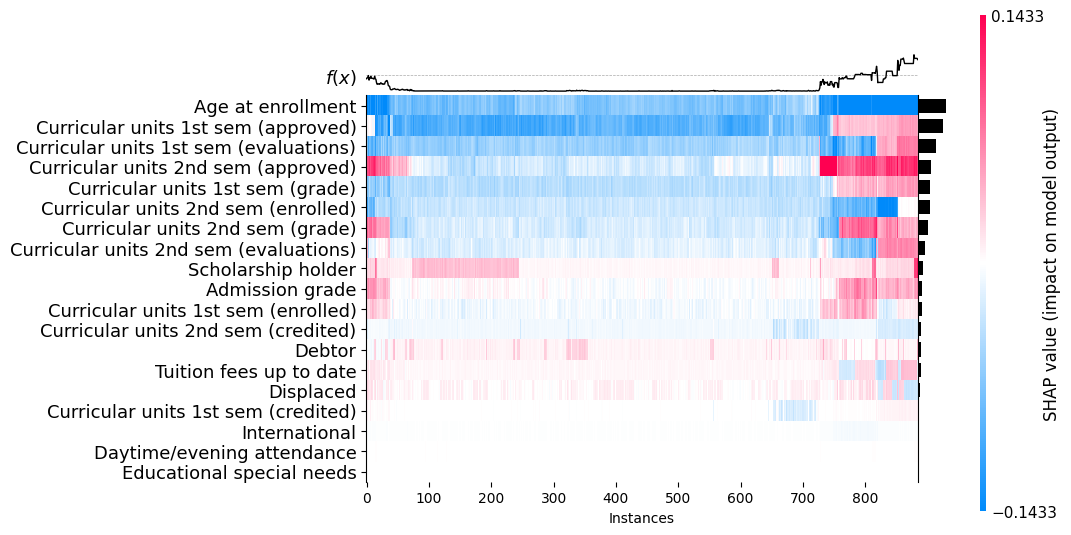

<Axes: xlabel='Instances'>

In [37]:
shap.plots.heatmap(shap_explanations["Dropout"], max_display=19)

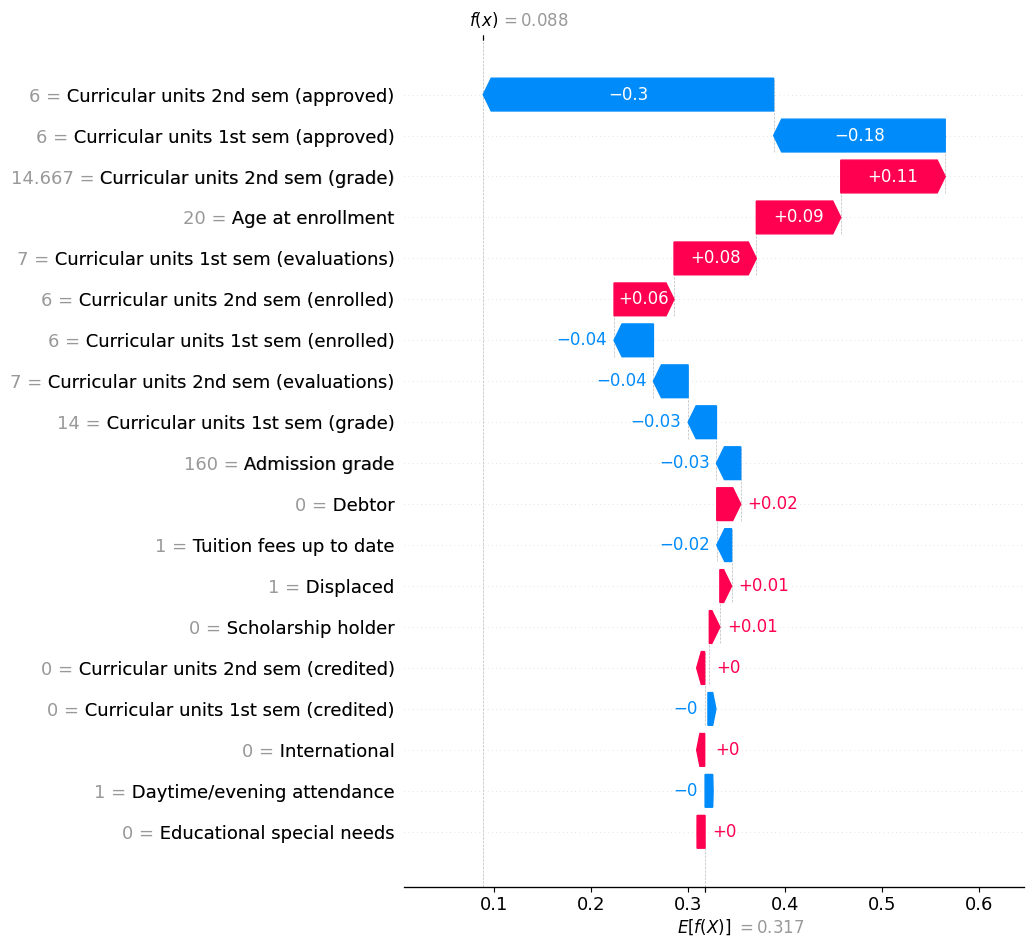

In [38]:
# Choose the dropout class index
dropout_class_index = 0

# Extract SHAP values for dropout class
dropout_shap = shap.Explanation(
    values=shap_values.values[..., dropout_class_index],
    base_values=shap_values.base_values[..., dropout_class_index],
    data=shap_values.data,
    feature_names=X_train_resampled.columns
)

# Pick one sample (student)
idx = 0  # or any student index

# Now plot safely
shap.plots.waterfall(dropout_shap[idx], max_display=len(X_selected.columns))


📘 Local explanation for Graduate:


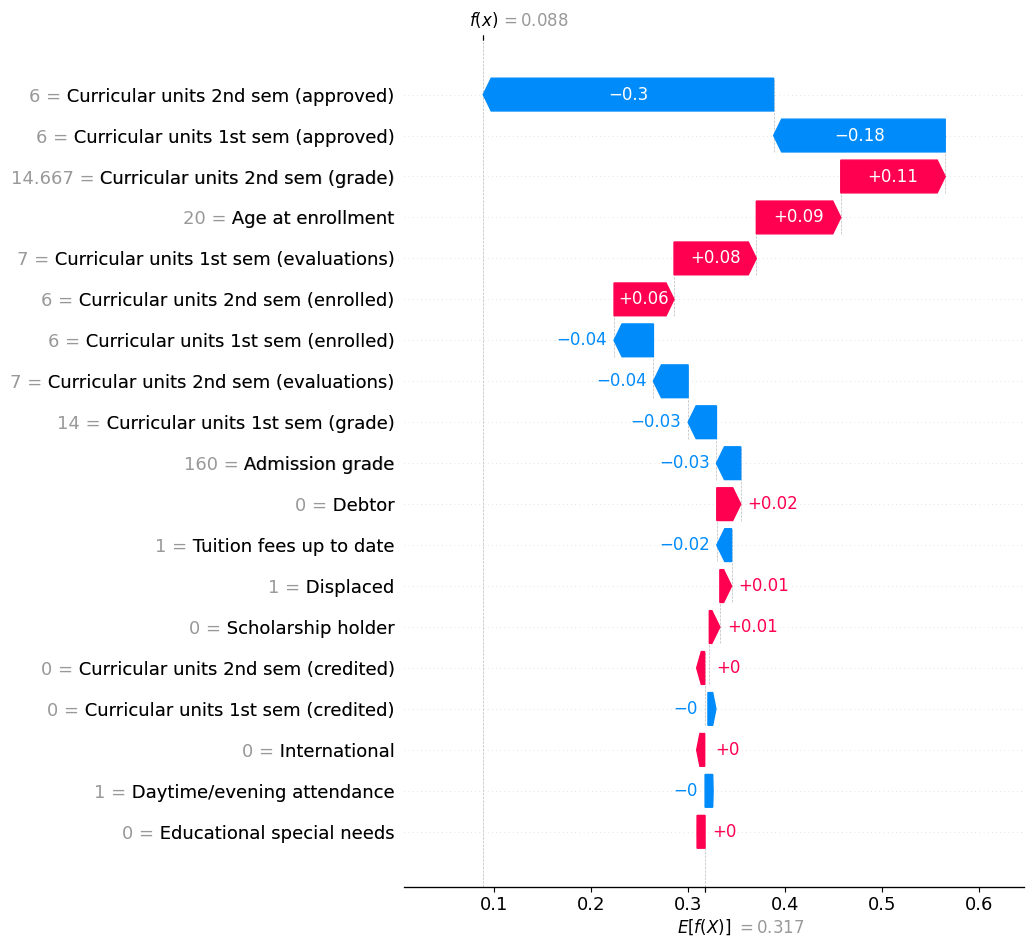


📘 Local explanation for Dropout:


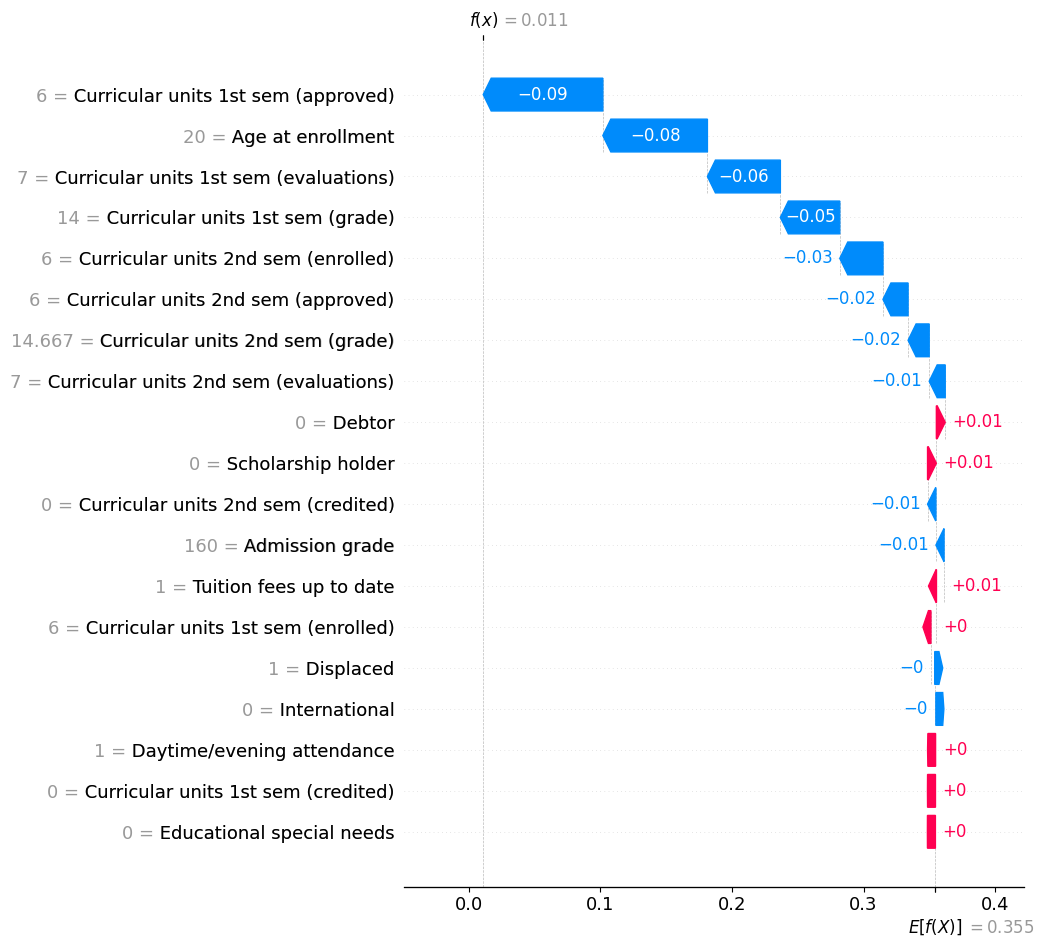


📘 Local explanation for Enrolled:


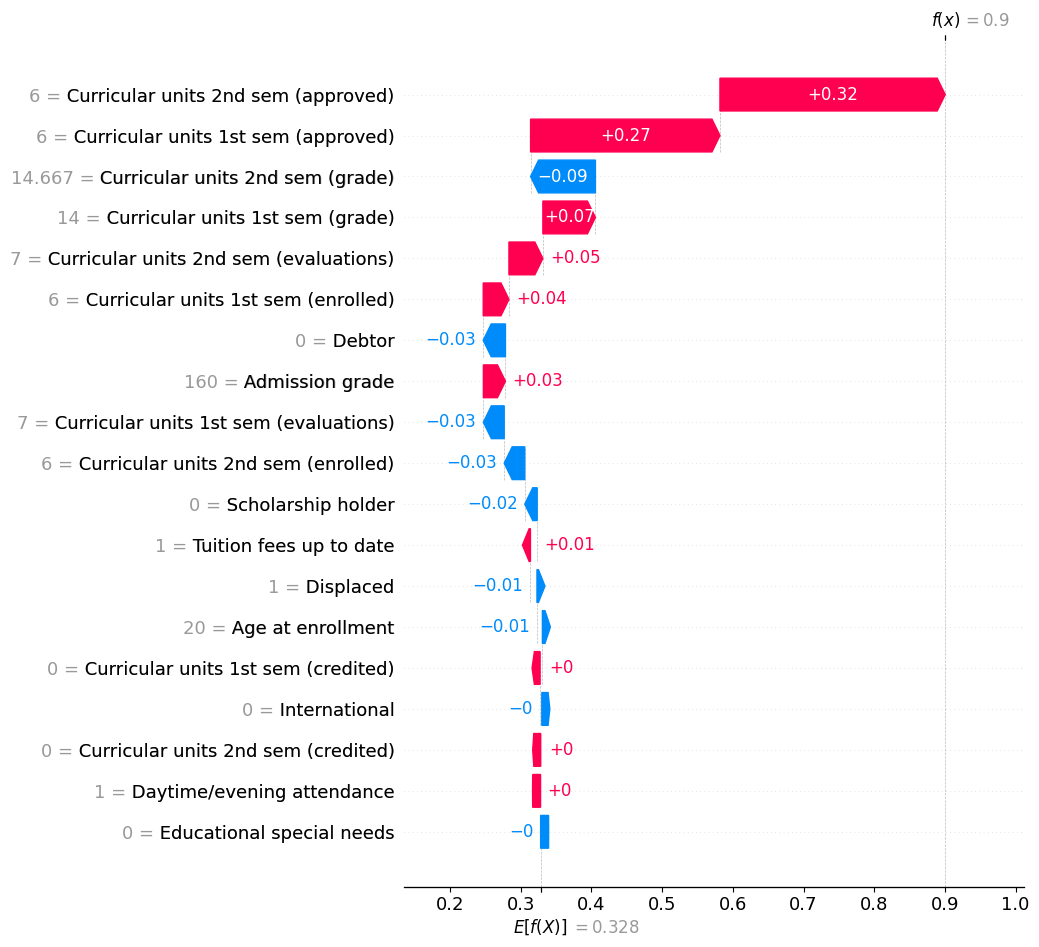

In [41]:
idx = 0
for cls in class_names:
    print(f"\n📘 Local explanation for {cls}:")
    shap.plots.waterfall(shap_explanations[cls][idx], max_display=19)

In [42]:
shap.initjs()
shap.force_plot(
    shap_explanations["Dropout"].base_values[idx],
    shap_explanations["Dropout"].values[idx],
    X_test_selected.iloc[idx],
    feature_names=X_train_resampled.columns
)

In [45]:
# SHAP scatter plot for Dropout class with feature names
shap.plots.scatter(shap_explanations["Dropout"], feature_names=X_train_resampled.columns)


# shap.plots.scatter(shap_explanations["Dropout"])

TypeError: scatter() got an unexpected keyword argument 'feature_names'